# LEAF RECOGNITION


In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import tqdm 
import time
import cv2
import matplotlib.pyplot as plt
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub


/kaggle/input/datasets/congdanhmaybedepzai/df-dataset/df_dataset.xls
/kaggle/input/datasets/congdanhmaybedepzai/df-dataset/df_testing_1.xls
/kaggle/input/datasets/congdanhmaybedepzai/df-dataset/df_testing_2.xls
/kaggle/input/datasets/congdanhmaybedepzai/leaf-dataset/Testing-1/Testing-1/cisds055.tif
/kaggle/input/datasets/congdanhmaybedepzai/leaf-dataset/Testing-1/Testing-1/fb056.tif
/kaggle/input/datasets/congdanhmaybedepzai/leaf-dataset/Testing-1/Testing-1/bint057.tif
/kaggle/input/datasets/congdanhmaybedepzai/leaf-dataset/Testing-1/Testing-1/b044.tif
/kaggle/input/datasets/congdanhmaybedepzai/leaf-dataset/Testing-1/Testing-1/begro043.tif
/kaggle/input/datasets/congdanhmaybedepzai/leaf-dataset/Testing-1/Testing-1/aw052.tif
/kaggle/input/datasets/congdanhmaybedepzai/leaf-dataset/Testing-1/Testing-1/ag044.tif
/kaggle/input/datasets/congdanhmaybedepzai/leaf-dataset/Testing-1/Testing-1/dracb055.tif
/kaggle/input/datasets/congdanhmaybedepzai/leaf-dataset/Testing-1/Testing-1/adv060.tif
/kag

In [2]:
import json
import joblib

from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Models
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    make_scorer
)

from sklearn.base import BaseEstimator, ClassifierMixin

## ML Model
- PNNs  + PCA
- SVM
- KNN

Methods: Standard Scaler + Grid Search + Pipeline to find the optimal parameters and save the evaluation metrics (accuracy, f1-score, precision, recall, confuse matrix)


In [3]:
# df_dataset = pd.read_csv("/kaggle/input/datasets/congdanhmaybedepzai/df-dataset/df_dataset.xls")
# df_test_1 = pd.read_csv("/kaggle/input/datasets/congdanhmaybedepzai/df-dataset/df_testing_1.xls")
# df_test_2 = pd.read_csv("/kaggle/input/datasets/congdanhmaybedepzai/df-dataset/df_testing_2.xls")

# df_dataset.head()

In [4]:
# print(df_dataset["path"][0])
# print(df_test_1["path"][0])

In [5]:
# # concat 
# df_test = pd.concat([df_test_1, df_test_2])
# print(df_test.shape)
# df = df_dataset.sample(frac = 1)
# print(df.head())

In [6]:
# print(df.columns)

In [7]:
# df = df.copy().drop(["path", "label"], axis = 1)
# df_test = df_test.copy().drop(["path", "label"], axis = 1)


In [8]:
# print(df.head)

In [9]:
# # prepare train, test 
# X_train = df.drop(columns=['numerical_label']).values
# y_train = df['numerical_label'].values

# X_test = df_test.drop(columns=['numerical_label']).values
# y_test = df_test['numerical_label'].values

In [10]:
# print(X_train.shape)
# print(y_train.shape)
# print(y_test.shape)
# print(X_test.shape)

In [11]:
# svm_pipeline = Pipeline([
#     ("scaler", StandardScaler()),
#     ("pca", PCA(whiten= True)),
#     ("svc", SVC())
# ])

# svm_param_grid = {
#     "pca__n_components": [30,40, 50, 57],
#     "svc__C": [1, 10, 100],
#     "svc__gamma": ["scale", 0.01],
#     "svc__kernel": ["rbf"]
# }
# cv = StratifiedKFold(
#     n_splits=5,
#     shuffle=True,
#     random_state=42
# )

# scoring = {
#     "accuracy": make_scorer(accuracy_score),
#     "f1": make_scorer(f1_score, average="macro"),
#     "precision": make_scorer(precision_score, average="macro"),
#     "recall": make_scorer(recall_score, average="macro")
# }

# grid_svm = GridSearchCV(
#     estimator= svm_pipeline,
#     param_grid=svm_param_grid,
#     cv = cv,
#     scoring= scoring, 
#     refit="accuracy",
#     n_jobs = -1,
#     verbose = 2,
#     return_train_score = True
# )

In [12]:
# start_time = time.perf_counter()

# grid_svm.fit(
#     X_train,
#     y_train
# )

# train_time = time.perf_counter() - start_time
# print("Best parameters:")
# print(grid_svm.best_params_)

# print("\nBest CV score:")
# print(grid_svm.best_score_)

# print("\nTraining time:")
# print(train_time)

In [13]:
# best_svm = grid_svm.best_estimator_
# start = time.perf_counter()

# y_pred = best_svm.predict(X_test)

# test_prediction_time = time.perf_counter() - start
# print("Testing time!")
# print(test_prediction_time)
# print("="*60)
# print("="*60)
# svm_metrics = classification_report(y_test, y_pred, output_dict = True)
# print(classification_report(y_test, y_pred))

In [14]:
# # precision / accuracy / f1-score / recall 
# history = {}
# svm_dict  = {
#     "precision": svm_metrics["macro avg"]["precision"],
#     "recall": svm_metrics["macro avg"]["recall"],
#     "f1-score":svm_metrics["macro avg"]["f1-score"],
#     "accuracy": svm_metrics["accuracy"]
# }
# history["svm"] = svm_dict

### PNNs Pipeline

In [15]:
# # build ppns class to be suitable for pipeline& gridsearch
# class PNNClassifier(BaseEstimator, ClassifierMixin):

#     def __init__(self, sigma=1.0):
#         self.sigma = sigma

#     def fit(self, X, y):

#         X = np.asarray(X, dtype=np.float64)
#         y = np.asarray(y)

#         self.X_train_ = X
#         self.y_train_ = y
#         self.classes_ = np.unique(y)

#         # Lưu index theo từng class
#         self.class_indices_ = {
#             c: np.where(y == c)[0]
#             for c in self.classes_
#         }

#         return self

#     def _gaussian_kernel_matrix(self, X):

#         """
#         Tính Gaussian kernel giữa:
#         X_test:  [n_test, n_features]
#         X_train: [n_train, n_features]

#         Output:
#         [n_test, n_train]
#         """

#         # ||x-y||²
#         X_sq = np.sum(X ** 2, axis=1, keepdims=True)

#         train_sq = np.sum(
#             self.X_train_ ** 2,
#             axis=1,
#             keepdims=True
#         ).T

#         distances_sq = (
#             X_sq
#             + train_sq
#             - 2 * X @ self.X_train_.T
#         )

#         distances_sq = np.maximum(
#             distances_sq,
#             0
#         )

#         sigma = max(
#             float(self.sigma),
#             1e-5
#         )

#         return np.exp(
#             -distances_sq /
#             (2 * sigma ** 2)
#         )

#     def predict(self, X):

#         X = np.asarray(
#             X,
#             dtype=np.float64
#         )

#         kernel = self._gaussian_kernel_matrix(X)

#         scores = []

#         for c in self.classes_:

#             idx = self.class_indices_[c]

#             # P(class | x)
#             class_score = np.mean(
#                 kernel[:, idx],
#                 axis=1
#             )

#             scores.append(class_score)

#         scores = np.column_stack(scores)

#         return self.classes_[
#             np.argmax(scores, axis=1)
#         ]

#     def predict_proba(self, X):

#         X = np.asarray(
#             X,
#             dtype=np.float64
#         )

#         kernel = self._gaussian_kernel_matrix(X)

#         scores = []

#         for c in self.classes_:

#             idx = self.class_indices_[c]

#             class_score = np.mean(
#                 kernel[:, idx],
#                 axis=1
#             )

#             scores.append(class_score)

#         scores = np.column_stack(scores)

#         # Normalize
#         denominator = np.sum(
#             scores,
#             axis=1,
#             keepdims=True
#         )

#         denominator = np.maximum(
#             denominator,
#             1e-12
#         )

#         return scores / denominator

In [16]:
# pnn_pipeline = Pipeline([
#     ("scaler", StandardScaler()),
#     ("pca", PCA(whiten=True, random_state = 2026)),
#     ("pnn", PNNClassifier())
# ])

# pnn_param_grid = {
#     "pca__n_components": [5,10,15,20,25,29],
#     "pnn__sigma": [0.01,0.05,0.1,0.2,0.5,1.0,2.0]
# }
# cv = StratifiedKFold(
#     n_splits=5,
#     shuffle=True,
#     random_state=42
# )
# scoring = {

#     "accuracy": make_scorer(
#         accuracy_score
#     ),

#     "f1": make_scorer(
#         f1_score,
#         average="macro",
#         zero_division=0
#     ),

#     "precision": make_scorer(
#         precision_score,
#         average="macro",
#         zero_division=0
#     ),

#     "recall": make_scorer(
#         recall_score,
#         average="macro",
#         zero_division=0
#     )
# }
# grid_pnn = GridSearchCV(
#     estimator=pnn_pipeline,
#     param_grid=pnn_param_grid,
#     cv=cv,
#     scoring=scoring,
#     refit="accuracy",
#     n_jobs=-1,
#     verbose=0,
#     return_train_score=True
# )

In [17]:
# start_time = time.perf_counter()

# grid_pnn.fit(
#     X_train,
#     y_train
# )

# train_time = time.perf_counter() - start_time
# print("Best parameters:")
# print(grid_pnn.best_params_)

# print("\nBest CV score:")
# print(grid_pnn.best_score_)

# print("\nTraining time:")
# print(train_time)

In [18]:
# best_pnn = grid_pnn.best_estimator_
# start = time.perf_counter()

# y_pred = best_pnn.predict(X_test)

# test_prediction_time = time.perf_counter() - start
# print("Testing time!")
# print(test_prediction_time)
# print("="*60)
# print("="*60)
# pnn_metrics = classification_report(y_test, y_pred, output_dict = True)
# print(classification_report(y_test, y_pred))

In [19]:
# # precision / accuracy / f1-score / recall 
# pnn_dict  = {
#     "precision": pnn_metrics["macro avg"]["precision"],
#     "recall": pnn_metrics["macro avg"]["recall"],
#     "f1-score": pnn_metrics["macro avg"]["f1-score"],
#     "accuracy": pnn_metrics["accuracy"]
# }
# history["pnn"] = pnn_dict

## DEEP LEARNING MODELS FOR CLASSIFITCATION.

### preparing Dataset.


In [20]:
import re
from pathlib import Path
BASE = Path("/kaggle/input/datasets/congdanhmaybedepzai/leaf-dataset")
DATASET_PATH = BASE / "Dataset"
TEST_1_PATH  = BASE / "Testing-1" / "Testing-1"  
TEST_2_PATH  = BASE / "Testing-2" / "Testing-2"   

VALID_EXT = {".tif", ".tiff"}

def extract_label(fp: Path, base:Path) -> str:
    if fp.parent != base: 
        return fp.parent.name
    match = re.match(r"^([a-zA-Z]+)", fp.stem) 
    return match.group(1) if match else fp.stem

def build_df(base: Path) -> pd.DataFrame:
    records = [
        {"path": str(fp), "label": extract_label(fp, base)}
        for fp in base.rglob("*")
        if fp.is_file()
        and fp.suffix.lower() in VALID_EXT
        and not any(p.startswith(".") for p in fp.parts)
    ]
    df = pd.DataFrame(records).sort_values("path").reset_index(drop=True)
    return df

df_dataset = build_df(DATASET_PATH)
df_test1   = build_df(TEST_1_PATH)
df_test2   = build_df(TEST_2_PATH)

# Verify
for name, df in [("Dataset", df_dataset), ("Testing-1", df_test1), ("Testing-2", df_test2)]:
    print(f"{name}: {len(df)} ảnh, {df['label'].nunique()} classes")
    print(f"  Ví dụ path: {df['path'].iloc[0]}")
    print(f"  Ví dụ label: {df['label'].iloc[0]}")
    print()

Dataset: 5999 ảnh, 60 classes
  Ví dụ path: /kaggle/input/datasets/congdanhmaybedepzai/leaf-dataset/Dataset/Dataset/E/E1.tif
  Ví dụ label: E

Testing-1: 600 ảnh, 30 classes
  Ví dụ path: /kaggle/input/datasets/congdanhmaybedepzai/leaf-dataset/Testing-1/Testing-1/E41.tif
  Ví dụ label: E

Testing-2: 600 ảnh, 30 classes
  Ví dụ path: /kaggle/input/datasets/congdanhmaybedepzai/leaf-dataset/Testing-2/Testing-2/K41.tif
  Ví dụ label: K



In [21]:
df_test = pd.concat([df_test1, df_test2], ignore_index = True)
print(len(df_test))

1200


In [22]:
df_dataset['label'] = df_dataset['label'].replace('jd', 'jg')
df_test['label'] = df_test['label'].replace('jd', 'jg')

In [23]:
df_dataset.head()

,path,label
0,/kaggle/input/datasets/congdanhmaybedepzai/lea...,E
1,/kaggle/input/datasets/congdanhmaybedepzai/lea...,E
2,/kaggle/input/datasets/congdanhmaybedepzai/lea...,E
3,/kaggle/input/datasets/congdanhmaybedepzai/lea...,E
4,/kaggle/input/datasets/congdanhmaybedepzai/lea...,E


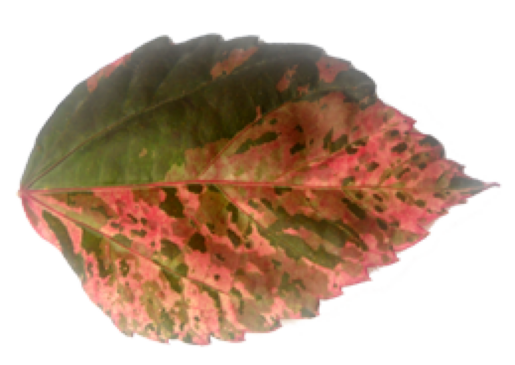

In [24]:
path = df_dataset['path'][0]
img = cv2.imread(path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

In [25]:
# check path
print(path)
print(df_test['path'][0])

/kaggle/input/datasets/congdanhmaybedepzai/leaf-dataset/Dataset/Dataset/E/E1.tif
/kaggle/input/datasets/congdanhmaybedepzai/leaf-dataset/Testing-1/Testing-1/E41.tif


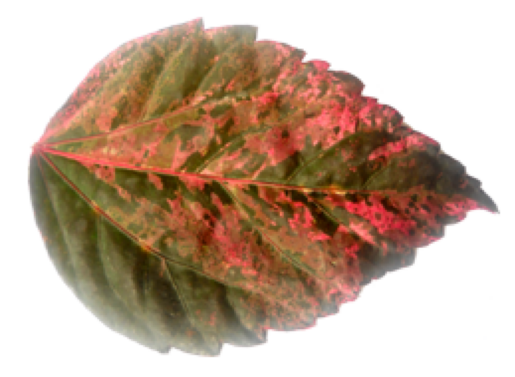

In [26]:
img = cv2.imread(df_test['path'][0])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

## Encoding Label for Dataset

In [27]:
# CATEGORICAL ENCODING FOR 3 DATAFRAME
classes = [   'adv',     'ag',     'ap',     'aw',      'b',  'beghi',  'begni',
 'begora',  'begro',   'bint',     'bl',  'caleg',  'cisds',   'cobm',
     'ct',     'cu',     'cv',     'dc',  'dracb',     'ds',      'E',
  'epiac',     'fb',  'fictr',     'gl',     'gr',    'grp',     'hi',
      'i',     'jg',      'K',    'kal',     'kl',     'ma',  'manes',
    'mar',     'mb',     'pb',    'pcj',    'per',  'pilna',  'pilnu',
  'piloy',  'pipcr',   'pmal',     'pr',     'ps',  'sciau',  'scimq',
      't',     'th',  'thuau',     'tw',   'ungu',      'w',     'wr',
      'X',      'Y',    'zam',  'zamcu']
# Tạo bảng tra cứu
class_to_idx = {cls_name: idx for idx, cls_name in enumerate(classes)}
idx_to_class = {idx: cls_name for idx, cls_name in enumerate(classes)}

for name, df in [("Dataset", df_dataset), ("Testing", df_test)]:
    print(f"Encoding Label for {name}")

    df["num_label"] = df["label"].map(class_to_idx)

    print(f"Ex: {df['path'].iloc[0]} : {df['num_label'].iloc[0]}")
    print("=" * 50)

Encoding Label for Dataset
Ex: /kaggle/input/datasets/congdanhmaybedepzai/leaf-dataset/Dataset/Dataset/E/E1.tif : 20
Encoding Label for Testing
Ex: /kaggle/input/datasets/congdanhmaybedepzai/leaf-dataset/Testing-1/Testing-1/E41.tif : 20


In [28]:
df_dataset.head()

,path,label,num_label
0,/kaggle/input/datasets/congdanhmaybedepzai/lea...,E,20
1,/kaggle/input/datasets/congdanhmaybedepzai/lea...,E,20
2,/kaggle/input/datasets/congdanhmaybedepzai/lea...,E,20
3,/kaggle/input/datasets/congdanhmaybedepzai/lea...,E,20
4,/kaggle/input/datasets/congdanhmaybedepzai/lea...,E,20


In [29]:
df_test.tail()

,path,label,num_label
1195,/kaggle/input/datasets/congdanhmaybedepzai/lea...,zamcu,59
1196,/kaggle/input/datasets/congdanhmaybedepzai/lea...,zamcu,59
1197,/kaggle/input/datasets/congdanhmaybedepzai/lea...,zamcu,59
1198,/kaggle/input/datasets/congdanhmaybedepzai/lea...,zamcu,59
1199,/kaggle/input/datasets/congdanhmaybedepzai/lea...,zamcu,59


In [30]:
df_dataset.isnull().sum()


path         0
label        0
num_label    0
dtype: int64

In [31]:
# PyTorch
from torch.utils.data import Dataset
from PIL import Image

class LeafDataset(Dataset):
    def __init__(self, df, transform=None):
        self.paths     = df["path"].values
        self.labels    = df["num_label"].values
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

### BUILD PIPELINE FOR RESNET.
    
  [1] Data Validation

  [2] Split Strategy

  [3] Xử lý ảnh không đồng kích thước

  [4] Augmentation

  [5] Dataset + DataLoader

  [6] Model ResNet

  [7] Training Strategy

  [8] Evaluation

### 1. DATA VALIDATION.

In [32]:
from PIL import Image
from tqdm import tqdm
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")
 
 
# ─────────────────────────────────────────────────────────────────────────────
class DataValidator:
    """
    Nhận DataFrame (path, label, num_label) → kiểm tra → trả về DataFrame sạch.
 
    Cách dùng:
        validator = DataValidator(df_train, name="Train")
        df_clean, report = validator.run()
        validator.plot_report()
    """
 
    def __init__(self, df: pd.DataFrame, name: str = "Dataset"):
        """
        Parameters
        ----------
        df   : DataFrame có ít nhất 3 cột: path, label, num_label
        name : tên hiển thị trong report (Train / Test1 / Test2)
        """
        # Làm việc trên bản copy — không sửa DataFrame gốc
        self.df_original = df.copy()
        self.name        = name
        self.report      = {}
        self.df_clean    = None
 
    # ── PRIVATE HELPERS ───────────────────────────────────────────────────────
 
    def _check_columns(self):
        """Đảm bảo các cột bắt buộc tồn tại."""
        required = {"path", "label", "num_label"}
        missing  = required - set(self.df_original.columns)
        if missing:
            raise ValueError(
                f"[{self.name}] DataFrame thiếu cột: {missing}\n"
                f"Các cột hiện có: {list(self.df_original.columns)}"
            )
 
    def _drop_nulls(self, df: pd.DataFrame) -> pd.DataFrame:
        """Bước A: Loại bỏ dòng có giá trị null."""
        null_mask = df.isnull().any(axis=1)
        n_null    = int(null_mask.sum())
 
        self.report["A_null_rows"] = n_null
        if n_null:
            null_cols = df.columns[df.isnull().any()].tolist()
            print(f"  [A] Null rows     : {n_null} dòng "
                  f"(cột bị ảnh hưởng: {null_cols})")
        else:
            print(f"  [A] Null rows     : 0 ✓")
 
        return df[~null_mask].copy()
 
    def _drop_invalid_labels(self, df: pd.DataFrame) -> pd.DataFrame:
        """Bước B: Loại bỏ num_label == -1 (ảnh không map được class)."""
        invalid_mask = df["num_label"] == -1
        n_invalid    = int(invalid_mask.sum())
 
        self.report["B_invalid_label"] = n_invalid
        if n_invalid:
            bad_labels = df.loc[invalid_mask, "label"].unique().tolist()
            print(f"  [B] Invalid label : {n_invalid} dòng "
                  f"(labels: {bad_labels})")
        else:
            print(f"  [B] Invalid label : 0 ✓")
 
        return df[~invalid_mask].copy()
 
    def _check_file_exists(self, df: pd.DataFrame) -> pd.DataFrame:
        """Bước C: Loại bỏ path không tồn tại trên disk."""
        exists_mask = df["path"].apply(os.path.exists)
        n_missing   = int((~exists_mask).sum())
 
        self.report["C_missing_files"] = n_missing
 
        if n_missing:
            missing_paths = df.loc[~exists_mask, "path"].tolist()
            print(f"  [C] Missing files : {n_missing} files")
            # In tối đa 5 path để debug
            for p in missing_paths[:5]:
                print(f"        ✗ {p}")
            if n_missing > 5:
                print(f"        ... và {n_missing - 5} file khác")
        else:
            print(f"  [C] Missing files : 0 ✓")
 
        return df[exists_mask].copy()
 
    def _scan_images(self, df: pd.DataFrame) -> pd.DataFrame:
        """
        Bước D: Thử decode từng ảnh để:
          - Phát hiện file corrupt
          - Thu thập width, height của mỗi ảnh
 
        Lưu ý: .verify() của PIL chỉ check header, không decode pixel.
        Cần np.array(img) để force decode thực sự.
        """
        readable_records = []
        corrupt_paths    = []
 
        print(f"  [D] Scanning {len(df)} images", end="")
        for _, row in tqdm(df.iterrows(), total=len(df),
                           desc="", ncols=60, leave=False):
            try:
                img  = Image.open(row["path"]).convert("RGB")
                w, h = img.size
                # Force decode pixel data — phát hiện corrupt thực sự
                np.array(img)
                readable_records.append({
                    "orig_index": row.name,
                    "img_width" : w,
                    "img_height": h,
                })
            except Exception as e:
                corrupt_paths.append((row["path"], str(e)))
 
        n_corrupt = len(corrupt_paths)
        self.report["D_corrupt_files"] = n_corrupt
 
        if n_corrupt:
            print(f"\n  [D] Corrupt files : {n_corrupt}")
            for p, err in corrupt_paths[:3]:
                print(f"        ✗ {os.path.basename(p)}: {err}")
        else:
            print(f"\n  [D] Corrupt files : 0 ✓")
 
        # Gán width/height vào DataFrame
        readable_df = pd.DataFrame(readable_records).set_index("orig_index")
        df_out = df.loc[readable_df.index].copy()
        df_out["img_width"]  = readable_df["img_width"]
        df_out["img_height"] = readable_df["img_height"]
 
        return df_out
 
    def _analyze_sizes(self, df: pd.DataFrame):
        """Bước E: Thống kê kích thước ảnh → khuyến nghị img_size."""
        widths  = df["img_width"].values
        heights = df["img_height"].values
        areas   = widths * heights
        ratios  = widths / heights  # > 1: nằm ngang, < 1: đứng
 
        size_stats = {
            "width"  : {"min": int(widths.min()),  "max": int(widths.max()),
                        "mean": float(widths.mean()), "median": float(np.median(widths))},
            "height" : {"min": int(heights.min()), "max": int(heights.max()),
                        "mean": float(heights.mean()), "median": float(np.median(heights))},
            "ratio"  : {"min": float(ratios.min()), "max": float(ratios.max()),
                        "mean": float(ratios.mean()), "median": float(np.median(ratios))},
        }
 
        # Gợi ý img_size: lấy percentile 75 của cạnh dài, làm tròn lên bội 32
        max_sides   = np.maximum(widths, heights)
        recommended = int(np.percentile(max_sides, 75))
        # Làm tròn lên bội 32 gần nhất (ResNet yêu cầu)
        recommended = ((recommended + 31) // 32) * 32
        recommended = max(recommended, 224)  # tối thiểu 224
 
        size_stats["recommended_img_size"] = recommended
 
        self.report["E_size_stats"]  = size_stats
        self.size_stats              = size_stats
 
        print(f"  [E] Width   range : {size_stats['width']['min']} – "
              f"{size_stats['width']['max']}  "
              f"(mean={size_stats['width']['mean']:.0f})")
        print(f"  [E] Height  range : {size_stats['height']['min']} – "
              f"{size_stats['height']['max']}  "
              f"(mean={size_stats['height']['mean']:.0f})")
        print(f"  [E] Ratio W/H     : {size_stats['ratio']['min']:.2f} – "
              f"{size_stats['ratio']['max']:.2f}  "
              f"(mean={size_stats['ratio']['mean']:.2f})")
        print(f"  [E] ✦ Recommended img_size: {recommended}×{recommended}")
 
    def _analyze_class_balance(self, df: pd.DataFrame):
        """Bước F: Thống kê số mẫu mỗi class."""
        dist     = df.groupby("num_label").size()
        n_cls    = len(dist)
        imbalance_ratio = dist.max() / dist.min() if dist.min() > 0 else float("inf")
 
        self.report["F_class_balance"] = {
            "n_classes"      : n_cls,
            "min_samples"    : int(dist.min()),
            "max_samples"    : int(dist.max()),
            "mean_samples"   : float(dist.mean()),
            "imbalance_ratio": float(imbalance_ratio),
        }
        self.class_dist = dist
 
        print(f"  [F] Classes       : {n_cls}")
        print(f"  [F] Samples/class : min={dist.min()}  "
              f"max={dist.max()}  mean={dist.mean():.1f}")
 
        if imbalance_ratio > 2.0:
            print(f"  [F] ⚠ Imbalance ratio = {imbalance_ratio:.1f} "
                  f"→ cân nhắc WeightedSampler")
        else:
            print(f"  [F] Imbalance ratio = {imbalance_ratio:.2f} ✓ cân bằng tốt")
 
    def _check_duplicates(self, df: pd.DataFrame) -> pd.DataFrame:
        """Bước G: Loại bỏ duplicate path (cùng 1 file bị thêm 2 lần)."""
        dup_mask = df["path"].duplicated(keep="first")
        n_dup    = int(dup_mask.sum())
 
        self.report["G_duplicate_paths"] = n_dup
        if n_dup:
            print(f"  [G] Duplicates    : {n_dup} dòng bị xóa (giữ lại lần đầu)")
        else:
            print(f"  [G] Duplicates    : 0 ✓")
 
        return df[~dup_mask].copy()
 
    # ── PUBLIC API ────────────────────────────────────────────────────────────
 
    def run(self, scan_images: bool = True) -> tuple:
        """
        Chạy toàn bộ validation pipeline.
 
        Parameters
        ----------
        scan_images : True = decode từng ảnh để check corrupt + lấy size.
                      False = bỏ qua bước này để nhanh hơn (không khuyến nghị
                      lần đầu chạy).
 
        Returns
        -------
        df_clean : DataFrame sạch, có thêm cột img_width, img_height
        report   : dict tóm tắt toàn bộ kết quả
        """
        print(f"\n{'='*55}")
        print(f"  DATA VALIDATION — {self.name}")
        print(f"  Input: {len(self.df_original)} rows")
        print(f"{'='*55}")
 
        self._check_columns()
        df = self.df_original.copy()
 
        df = self._drop_nulls(df)            # A
        df = self._drop_invalid_labels(df)   # B
        df = self._check_file_exists(df)     # C
 
        if scan_images:
            df = self._scan_images(df)       # D — decode + lấy size
            self._analyze_sizes(df)          # E
        else:
            print("  [D] Image scan    : skipped")
            print("  [E] Size stats    : skipped")
            df["img_width"]  = -1
            df["img_height"] = -1
 
        self._analyze_class_balance(df)      # F
        df = self._check_duplicates(df)      # G
 
        # Reset index sau khi clean
        df = df.reset_index(drop=True)
        self.df_clean = df
 
        # Tổng kết
        n_removed = len(self.df_original) - len(df)
        self.report["summary"] = {
            "input_rows"  : len(self.df_original),
            "output_rows" : len(df),
            "removed_rows": n_removed,
            "removal_pct" : round(n_removed / len(self.df_original) * 100, 2),
        }
 
        print(f"\n{'─'*55}")
        print(f"  Kết quả: {len(self.df_original)} → {len(df)} dòng "
              f"(-{n_removed}, {self.report['summary']['removal_pct']}%)")
        print(f"{'='*55}\n")
 
        return df, self.report
 
    def plot_report(self, figsize: tuple = (16, 10)):
        """
        Visualize kết quả validation:
          - Class distribution (bar chart)
          - Width distribution (histogram)
          - Height distribution (histogram)
          - Aspect ratio distribution (histogram)
        """
        if self.df_clean is None:
            raise RuntimeError("Chạy .run() trước khi plot.")
 
        df   = self.df_clean
        has_size = df["img_width"].iloc[0] != -1
 
        n_plots = 4 if has_size else 1
        fig, axes = plt.subplots(1, n_plots, figsize=figsize)
        if n_plots == 1:
            axes = [axes]
 
        # ── 1. Class distribution ──
        ax = axes[0]
        dist = df.groupby("num_label").size().sort_index()
        ax.bar(dist.index, dist.values, color="steelblue", alpha=0.8, edgecolor="white")
        ax.axhline(y=dist.mean(), color="red", linestyle="--",
                   linewidth=1.5, label=f"Mean = {dist.mean():.0f}")
        ax.set_title(f"Class Distribution\n({len(dist)} classes)", fontsize=12)
        ax.set_xlabel("Class index")
        ax.set_ylabel("Số ảnh")
        ax.legend(fontsize=9)
        ax.grid(axis="y", alpha=0.3)
 
        if has_size:
            # ── 2. Width histogram ──
            axes[1].hist(df["img_width"], bins=20, color="teal", alpha=0.8, edgecolor="white")
            axes[1].axvline(df["img_width"].median(), color="red", linestyle="--",
                            label=f"Median = {df['img_width'].median():.0f}")
            axes[1].set_title("Image Width Distribution", fontsize=12)
            axes[1].set_xlabel("Width (pixels)")
            axes[1].set_ylabel("Số ảnh")
            axes[1].legend(fontsize=9)
            axes[1].grid(alpha=0.3)
 
            # ── 3. Height histogram ──
            axes[2].hist(df["img_height"], bins=20, color="coral", alpha=0.8, edgecolor="white")
            axes[2].axvline(df["img_height"].median(), color="navy", linestyle="--",
                            label=f"Median = {df['img_height'].median():.0f}")
            axes[2].set_title("Image Height Distribution", fontsize=12)
            axes[2].set_xlabel("Height (pixels)")
            axes[2].set_ylabel("Số ảnh")
            axes[2].legend(fontsize=9)
            axes[2].grid(alpha=0.3)
 
            # ── 4. Aspect ratio ──
            ratios = df["img_width"] / df["img_height"]
            axes[3].hist(ratios, bins=20, color="mediumpurple", alpha=0.8, edgecolor="white")
            axes[3].axvline(1.0, color="red", linestyle="-", linewidth=2,
                            label="Square (1:1)")
            axes[3].axvline(ratios.median(), color="orange", linestyle="--",
                            label=f"Median = {ratios.median():.2f}")
            axes[3].set_title("Aspect Ratio (W/H)\n<1 = portrait  >1 = landscape",
                              fontsize=12)
            axes[3].set_xlabel("Width / Height")
            axes[3].set_ylabel("Số ảnh")
            axes[3].legend(fontsize=9)
            axes[3].grid(alpha=0.3)
 
        plt.suptitle(
            f"Data Validation Report — {self.name}  "
            f"({self.report['summary']['output_rows']} ảnh hợp lệ)",
            fontsize=14, fontweight="bold", y=1.02,
        )
        plt.tight_layout()
        plt.show()
 
    def print_size_recommendation(self):
        """In rõ khuyến nghị img_size để dùng ở bước Augmentation."""
        if "E_size_stats" not in self.report:
            print("Chạy run(scan_images=True) trước.")
            return
 
        stats = self.report["E_size_stats"]
        rec   = stats["recommended_img_size"]
 
        print(f"\n{'─'*50}")
        print(f"  IMG_SIZE RECOMMENDATION — {self.name}")
        print(f"{'─'*50}")
        print(f"  Width  : {stats['width']['min']} – {stats['width']['max']}"
              f"  (mean={stats['width']['mean']:.0f})")
        print(f"  Height : {stats['height']['min']} – {stats['height']['max']}"
              f"  (mean={stats['height']['mean']:.0f})")
        print(f"  Ratio  : {stats['ratio']['min']:.2f} – {stats['ratio']['max']:.2f}"
              f"  (mean={stats['ratio']['mean']:.2f})")
        print(f"\n  ✦ Dùng IMG_SIZE = {rec} cho bước [3] & [4]")
        print(f"    (percentile 75 của cạnh dài, làm tròn lên bội 32)")
        print(f"{'─'*50}\n")
 
 
# ─────────────────────────────────────────────────────────────────────────────
# CONVENIENCE FUNCTION — validate nhiều bộ cùng lúc
# ─────────────────────────────────────────────────────────────────────────────
def validate_all(
    df_train : pd.DataFrame,
    df_test1 : pd.DataFrame,
    df_test2 : pd.DataFrame,
    scan_images: bool = True,
) -> tuple:
    """
    Validate 3 bộ data cùng lúc.
 
    Returns
    -------
    df_train_clean, df_test1_clean, df_test2_clean, reports
    """
    results = {}
    cleaned = {}
 
    for name, df in [("Train/Val", df_train),
                     ("Testing-1", df_test1),
                     ("Testing-2", df_test2)]:
        validator       = DataValidator(df, name=name)
        df_clean, report = validator.run(scan_images=scan_images)
        cleaned[name]   = df_clean
        results[name]   = report
 
        if scan_images:
            validator.print_size_recommendation()
 
    # Khuyến nghị img_size cuối cùng (lấy max của 3 bộ)
    if scan_images:
        rec_sizes = [
            r["E_size_stats"]["recommended_img_size"]
            for r in results.values()
            if "E_size_stats" in r
        ]
        if rec_sizes:
            final_rec = max(rec_sizes)
            print(f"{'='*50}")
            print(f"  FINAL RECOMMENDATION: IMG_SIZE = {final_rec}")
            print(f"  (max của 3 bộ → đảm bảo không mất thông tin)")
            print(f"  → Dùng giá trị này cho STEP 3 & 4")
            print(f"{'='*50}\n")
 
    return (
        cleaned["Train/Val"],
        cleaned["Testing-1"],
        cleaned["Testing-2"],
        results,
    )


  DATA VALIDATION — Dataset-training
  Input: 5999 rows
  [A] Null rows     : 0 ✓
  [B] Invalid label : 0 ✓
  [C] Missing files : 0 ✓
  [D] Scanning 5999 images


  [D] Corrupt files : 0 ✓
  [E] Width   range : 150 – 820  (mean=250)
  [E] Height  range : 55 – 1996  (mean=285)
  [E] Ratio W/H     : 0.16 – 4.55  (mean=1.18)
  [E] ✦ Recommended img_size: 352×352
  [F] Classes       : 60
  [F] Samples/class : min=99  max=100  mean=100.0
  [F] Imbalance ratio = 1.01 ✓ cân bằng tốt
  [G] Duplicates    : 0 ✓

───────────────────────────────────────────────────────
  Kết quả: 5999 → 5999 dòng (-0, 0.0%)


──────────────────────────────────────────────────
  IMG_SIZE RECOMMENDATION — Dataset-training
──────────────────────────────────────────────────
  Width  : 150 – 820  (mean=250)
  Height : 55 – 1996  (mean=285)
  Ratio  : 0.16 – 4.55  (mean=1.18)

  ✦ Dùng IMG_SIZE = 352 cho bước [3] & [4]
    (percentile 75 của cạnh dài, làm tròn lên bội 32)
──────────────────────────────────────────────────



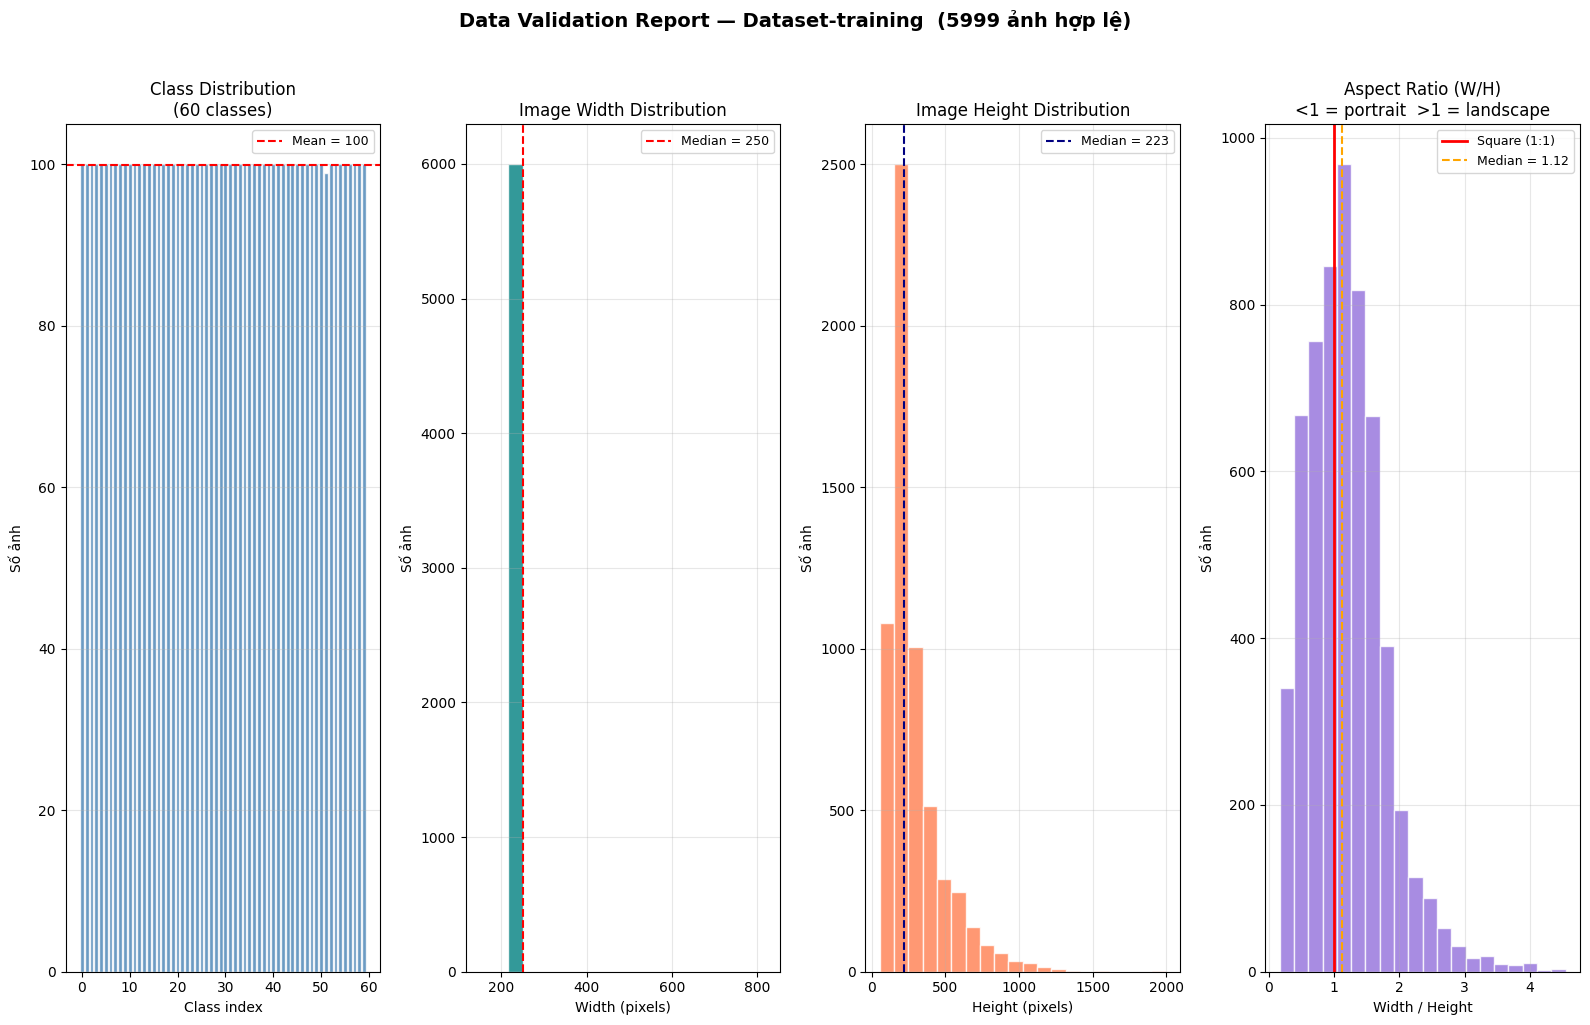

df_clean columns: ['path', 'label', 'num_label', 'img_width', 'img_height']
                                                path label  num_label  \
0  /kaggle/input/datasets/congdanhmaybedepzai/lea...     E         20   
1  /kaggle/input/datasets/congdanhmaybedepzai/lea...     E         20   
2  /kaggle/input/datasets/congdanhmaybedepzai/lea...     E         20   
3  /kaggle/input/datasets/congdanhmaybedepzai/lea...     E         20   
4  /kaggle/input/datasets/congdanhmaybedepzai/lea...     E         20   

   img_width  img_height  
0        250         174  
1        250         175  
2        250         164  
3        250         147  
4        250         168  


In [33]:
validator = DataValidator(df_dataset, name = "Dataset-training")
df_clean, report = validator.run(scan_images = True)
validator.print_size_recommendation()
validator.plot_report()
print("df_clean columns:", df_clean.columns.tolist())
print(df_clean.head())

In [34]:
# kiem tra len dataset_training
print(len(classes))
print(len(df_dataset['label'].unique()))
print(len(df_dataset['num_label'].unique()))

60
60
60


In [35]:
df_dataset[df_dataset['num_label'].isnull()]['label'].value_counts()

Series([], Name: count, dtype: int64)


  DATA VALIDATION — Dataset-testing
  Input: 1200 rows
  [A] Null rows     : 0 ✓
  [B] Invalid label : 0 ✓
  [C] Missing files : 0 ✓
  [D] Scanning 1200 images


  [D] Corrupt files : 0 ✓
  [E] Width   range : 250 – 250  (mean=250)
  [E] Height  range : 67 – 1297  (mean=266)
  [E] Ratio W/H     : 0.19 – 3.73  (mean=1.22)
  [E] ✦ Recommended img_size: 320×320
  [F] Classes       : 60
  [F] Samples/class : min=20  max=20  mean=20.0
  [F] Imbalance ratio = 1.00 ✓ cân bằng tốt
  [G] Duplicates    : 0 ✓

───────────────────────────────────────────────────────
  Kết quả: 1200 → 1200 dòng (-0, 0.0%)


──────────────────────────────────────────────────
  IMG_SIZE RECOMMENDATION — Dataset-testing
──────────────────────────────────────────────────
  Width  : 250 – 250  (mean=250)
  Height : 67 – 1297  (mean=266)
  Ratio  : 0.19 – 3.73  (mean=1.22)

  ✦ Dùng IMG_SIZE = 320 cho bước [3] & [4]
    (percentile 75 của cạnh dài, làm tròn lên bội 32)
──────────────────────────────────────────────────



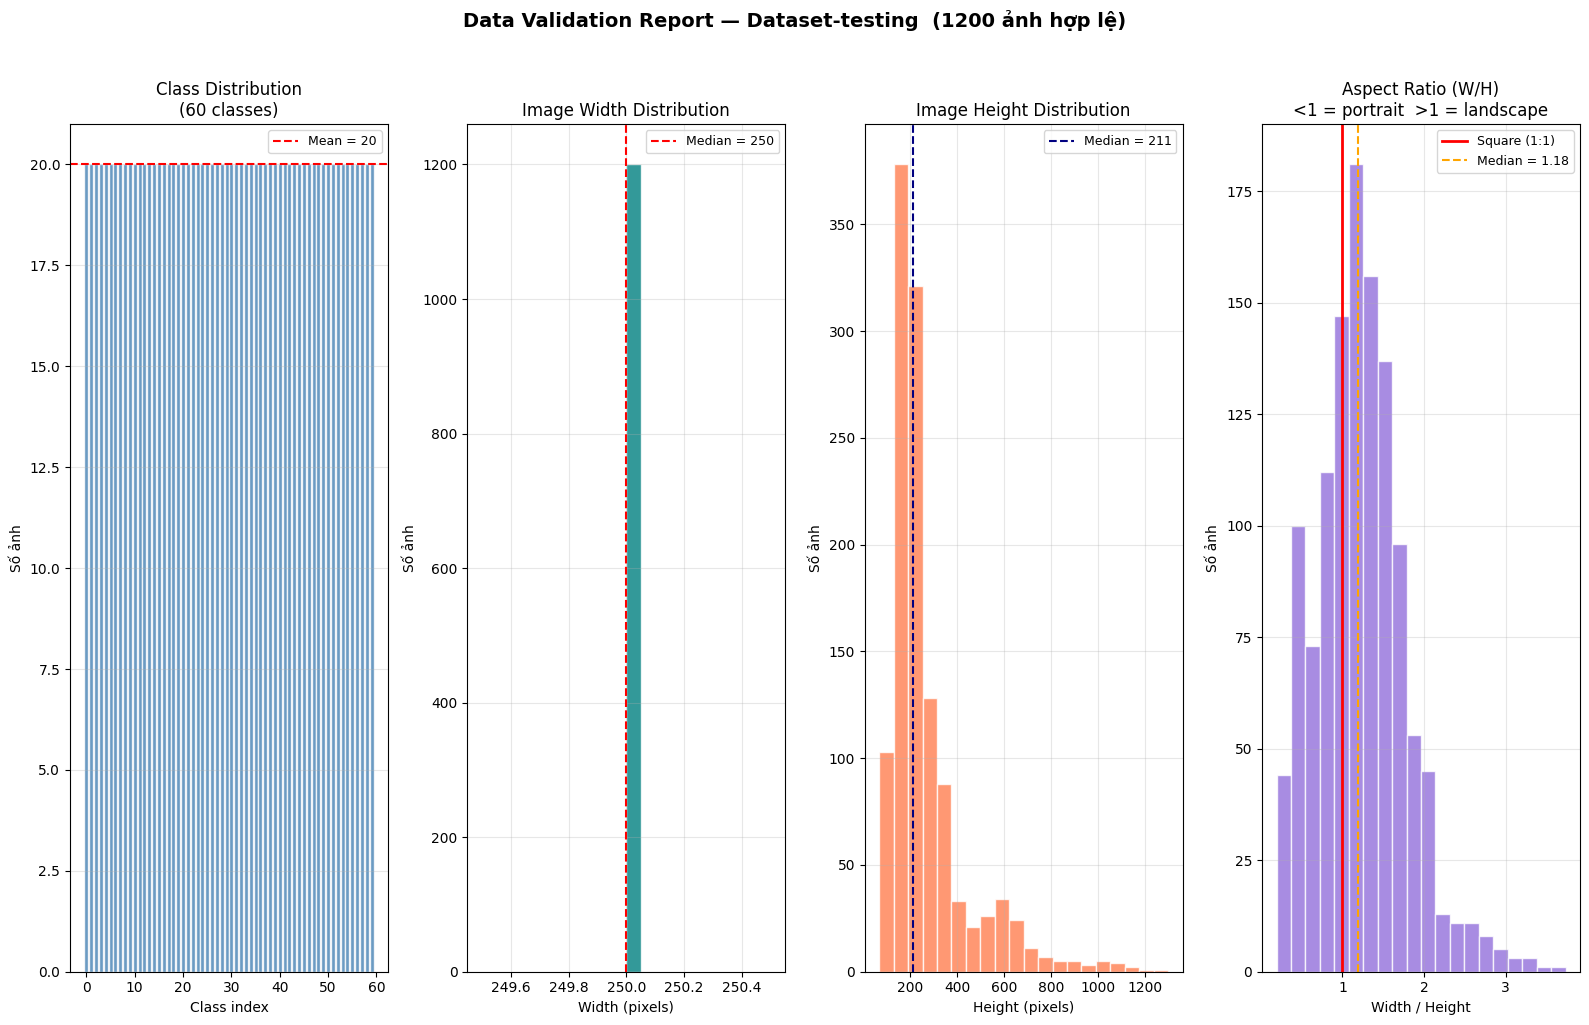

df_clean columns: ['path', 'label', 'num_label', 'img_width', 'img_height']
                                                path label  num_label  \
0  /kaggle/input/datasets/congdanhmaybedepzai/lea...     E         20   
1  /kaggle/input/datasets/congdanhmaybedepzai/lea...     E         20   
2  /kaggle/input/datasets/congdanhmaybedepzai/lea...     E         20   
3  /kaggle/input/datasets/congdanhmaybedepzai/lea...     E         20   
4  /kaggle/input/datasets/congdanhmaybedepzai/lea...     E         20   

   img_width  img_height  
0        250         180  
1        250         163  
2        250         159  
3        250         162  
4        250         168  


In [36]:
validator = DataValidator(df_test, name = "Dataset-testing")
df_test_clean, report = validator.run(scan_images = True)
validator.print_size_recommendation()
validator.plot_report()
print("df_clean columns:", df_test_clean.columns.tolist())
print(df_test_clean.head())

### 2.SPLIT DATA

In [37]:
from sklearn.model_selection import train_test_split
df_train, df_val = train_test_split(
    df_clean, test_size = 0.1, stratify =df_clean['num_label'], random_state = 2026
)


### 3. TRANSFORM AND PADDING.

In [38]:
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import torch

IMAGENET_MEAN_PIXEL = (123, 116, 103)   # = (0.485*255, 0.456*255, 0.406*255)
IMAGENET_MEAN       = [0.485, 0.456, 0.406]
IMAGENET_STD        = [0.229, 0.224, 0.225]

class ResizeWithPad: 
    def __init__(
        self,
        target_size: int = 224,
        fill_color: tuple = IMAGENET_MEAN_PIXEL,
        interpolation = Image.BILINEAR,
    ):
        self.target_size = target_size
        self.fill_color = fill_color
        self.interpolation = interpolation

    def __call__(self, img: Image.Image) -> Image.Image: 
        if img.mode != "RGB":
            img = img.convert("RGB")
            
        w, h = img.size
        T_size = self.target_size

        scale = T_size / max(w, h)
        new_w = max(1, int(round(w * scale)))
        new_h = max(1, int(round(h * scale)))
        img_resized = img.resize((new_w, new_h), self.interpolation)
        
        # Canvas với màu ImageNet Mean
        canvas = Image.new("RGB", (T_size, T_size), self.fill_color)
        
        # Canh giữa ảnh theo (x, y) = (pad_left, pad_top)
        pad_left = (T_size - new_w) // 2 
        pad_top = (T_size - new_h) // 2
        canvas.paste(img_resized, (pad_left, pad_top))

        return canvas

    def __repr__(self):
        return (f"ResizeWithPad(target_size={self.target_size}, "
                f"fill_color={self.fill_color})")


def get_transform(split: str, img_size: int = 224) -> T.Compose:
    """
    Trả về transform pipeline hoàn chỉnh cho từng split.
 
    split = "train" : ResizeWithPad → Augmentation → ToTensor → Normalize
    split = "val"   : ResizeWithPad → ToTensor → Normalize  (không augment)
    split = "test"  : Giống val
    """
    resize_pad = ResizeWithPad(target_size=img_size)
 
    if split == "train":
        return T.Compose([
            # ── [3] Resize giữ tỉ lệ + Pad ──
            resize_pad,
 
            # ── [4] Augmentation chỉ cho train ──
            T.RandomHorizontalFlip(p=0.5),
            T.RandomVerticalFlip(p=0.3),
            T.RandomRotation(degrees=30),
 
            # Color jitter nhẹ nhàng bảo tồn đặc trưng loài lá
            T.ColorJitter(
                brightness = 0.3,
                contrast   = 0.3,
                saturation = 0.2,
                hue        = 0.05,
            ),
 
            # ── Convert + Normalize ──
            T.ToTensor(),
            T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])
    else:  # "val" hoặc "test"
        return T.Compose([
            resize_pad,
            T.ToTensor(),
            T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])

In [39]:
def get_transform(split: str, img_size: int = 224) -> T.Compose:
    """
    Trả về transform pipeline hoàn chỉnh cho từng split.
 
    split = "train" : ResizeWithPad → Augmentation → ToTensor → Normalize
    split = "val"   : ResizeWithPad → ToTensor → Normalize  (không augment)
    split = "test"  : Giống val
 
    Parameters
    ----------
    split    : "train" | "val" | "test"
    img_size : kích thước output (từ Step 1 recommendation, thường 224 hoặc 320)
 
    Returns
    -------
    torchvision.transforms.Compose
    """
    # Bước chung: Cách B resize + pad
    resize_pad = ResizeWithPad(target_size=img_size)
 
    if split == "train":
        return T.Compose([
            # ── [3] Resize giữ tỉ lệ + Pad ──
            resize_pad,
 
            # ── [4] Augmentation chỉ cho train ──
            # Geometric
            T.RandomHorizontalFlip(p=0.5),
            T.RandomVerticalFlip(p=0.3),
            T.RandomRotation(degrees=30),
 
            # Color — nhẹ tay vì ảnh lá có màu đặc trưng theo loài
            T.ColorJitter(
                brightness = 0.3,
                contrast   = 0.3,
                saturation = 0.2,
                hue        = 0.05,  # hue nhỏ — lá xanh không nên thành đỏ
            ),
 
            # ── Convert + Normalize ──
            T.ToTensor(),
            T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])
 
    else:  # val hoặc test
        return T.Compose([
            # ── [3] Resize giữ tỉ lệ + Pad — không augment ──
            resize_pad,
 
            T.ToTensor(),
            T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
        ])
 
 
# ─────────────────────────────────────────────────────────────────────────────
# VISUALIZATION — kiểm tra transform trước khi train
# ─────────────────────────────────────────────────────────────────────────────
def visualize_padding(
    img_pil    : Image.Image,
    img_size   : int = 224,
    label      : str = "",
    n_augment  : int = 4,
):
    """
    Hiển thị 3 panel:
      - Ảnh gốc (với kích thước thực)
      - Sau ResizeWithPad (val transform — không augment)
      - N bản augmented khác nhau (train transform)
 
    Dùng để verify transform hoạt động đúng trước khi train.
    """
    val_tf   = get_transform("val",   img_size)
    train_tf = get_transform("train", img_size)
 
    # Denormalize để hiện thị đúng màu
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
 
    def to_display(tensor):
        img = tensor * std + mean
        img = img.clamp(0, 1).permute(1, 2, 0).numpy()
        return img
 
    n_cols = 2 + n_augment
    fig, axes = plt.subplots(1, n_cols, figsize=(3 * n_cols, 4))
 
    # ── Panel 1: Ảnh gốc ──
    axes[0].imshow(np.array(img_pil))
    axes[0].set_title(
        f"Gốc\n{img_pil.size[0]}×{img_pil.size[1]}\n"
        f"ratio={img_pil.size[0]/img_pil.size[1]:.2f}",
        fontsize=9,
    )
    axes[0].axis("off")
 
    # Vẽ border đỏ để thấy rõ kích thước
    for spine in axes[0].spines.values():
        spine.set_edgecolor("red")
        spine.set_linewidth(2)
 
    # ── Panel 2: Val transform (ResizeWithPad, không augment) ──
    val_tensor  = val_tf(img_pil)
    val_display = to_display(val_tensor)
    axes[1].imshow(val_display)
 
    # Tìm vùng padding (pixel gần 0 sau normalize)
    pad_mask = (np.abs(val_display - np.array(IMAGENET_MEAN_PIXEL)/255) < 0.05).all(axis=2)
    leaf_pct = (1 - pad_mask.mean()) * 100
 
    axes[1].set_title(
        f"Val Transform\n{img_size}×{img_size}\n"
        f"Lá chiếm {leaf_pct:.0f}%",
        fontsize=9,
    )
    axes[1].axis("off")
 
    # ── Panel 3+: Train transform (augmented) ──
    for i in range(n_augment):
        train_tensor  = train_tf(img_pil)
        train_display = to_display(train_tensor)
        axes[2 + i].imshow(train_display)
        axes[2 + i].set_title(f"Train aug #{i+1}", fontsize=9)
        axes[2 + i].axis("off")
 
    plt.suptitle(
        f"ResizeWithPad — {label}  (img_size={img_size})",
        fontsize=12, fontweight="bold",
    )
    plt.tight_layout()
    plt.show()
 
 
def visualize_batch_diversity(
    img_paths  : list,
    img_size   : int = 224,
    n_show     : int = 6,
):
    """
    Hiển thị nhiều ảnh khác nhau qua Val transform để kiểm tra:
      - Ảnh portrait, landscape, square đều được xử lý đúng
      - Padding luôn ở đúng vị trí center
    """
    val_tf = get_transform("val", img_size)
    mean   = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std    = torch.tensor(IMAGENET_STD).view(3, 1, 1)
 
    paths_show = img_paths[:n_show]
    fig, axes  = plt.subplots(2, len(paths_show), figsize=(3 * len(paths_show), 6))
 
    for i, path in enumerate(paths_show):
        img  = Image.open(path).convert("RGB")
        w, h = img.size
 
        # Row 1: ảnh gốc
        axes[0, i].imshow(np.array(img))
        axes[0, i].set_title(f"{w}×{h}\nratio={w/h:.2f}", fontsize=8)
        axes[0, i].axis("off")
 
        # Row 2: sau transform
        tensor  = val_tf(img)
        display = (tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
        axes[1, i].imshow(display)
        axes[1, i].set_title(f"{img_size}×{img_size}", fontsize=8)
        axes[1, i].axis("off")
 
    axes[0, 0].set_ylabel("Ảnh gốc", fontsize=10)
    axes[1, 0].set_ylabel("Sau padding", fontsize=10)
 
    plt.suptitle(
        f"Kiểm tra ResizeWithPad trên nhiều ảnh (img_size={img_size})",
        fontsize=12, fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

In [40]:
import os
import re
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets
from sklearn.model_selection import StratifiedShuffleSplit

# Đường dẫn bộ dữ liệu trên Kaggle
KAGGLE_DATA_DIR = Path("/kaggle/input/datasets/congdanhmaybedepzai/leaf-dataset")
train_dir = KAGGLE_DATA_DIR / "Dataset" / "Dataset"
test1_dir = KAGGLE_DATA_DIR / "Testing-1" / "Testing-1"
test2_dir = KAGGLE_DATA_DIR / "Testing-2" / "Testing-2"

# 1. Nạp Dataset gốc bằng ImageFolder
full_train_dataset = datasets.ImageFolder(root=str(train_dir))
class_to_idx = full_train_dataset.class_to_idx

# Đồng bộ sửa lỗi nhãn gõ nhầm 'jd' -> 'jg' (Celosia spicata)
if "jd" in class_to_idx and "jg" not in class_to_idx:
    class_to_idx["jg"] = class_to_idx.pop("jd")

# 2. Phân tầng: 85% Train, 15% Validation (StratifiedShuffleSplit)
targets = full_train_dataset.targets
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=2026)
train_indices, val_indices = next(sss.split(targets, targets))

class FoliageTransformedSubset(Dataset):
    """Bọc Subset để gán riêng transforms cho Train và Val."""
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
        
    def __len__(self):
        return len(self.subset)
        
    def __getitem__(self, idx):
        path, target = self.subset.dataset.samples[self.subset.indices[idx]]
        img = Image.open(path).convert("RGB")
        return self.transform(img), target

train_dataset = FoliageTransformedSubset(Subset(full_train_dataset, train_indices), get_transform("train", img_size=224))
val_dataset   = FoliageTransformedSubset(Subset(full_train_dataset, val_indices),   get_transform("val",   img_size=224))

# 3. Nạp tập Test ngoại kiểm (Testing-1 và Testing-2: 600 + 600 = 1200 ảnh)
class FoliageFlatTestDataset(Dataset):
    def __init__(self, test_folders, class_mapping, transform):
        self.samples = []
        self.transform = transform
        
        for folder in test_folders:
            if not folder.exists():
                continue
            for img_p in folder.glob("*.tif"):
                if img_p.name == "desktop.ini":
                    continue
                # Trích xuất tiền tố chữ trước các con số (vd: jg060.tif -> jg)
                raw_prefix = re.split(r'\d+', img_p.stem)[0].strip()
                label = "jg" if raw_prefix == "jd" else raw_prefix
                if label in class_mapping:
                    self.samples.append((str(img_p), class_mapping[label]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_p, target = self.samples[idx]
        img = Image.open(img_p).convert("RGB")
        return self.transform(img), target

test_dataset = FoliageFlatTestDataset([test1_dir, test2_dir], class_to_idx, get_transform("test", img_size=224))

# 4. Khởi tạo DataLoaders tối ưu cho GPU
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"✓ Tập Train : {len(train_dataset)} ảnh (85 ảnh/loài)")
print(f"✓ Tập Val   : {len(val_dataset)} ảnh (15 ảnh/loài)")
print(f"✓ Tập Test  : {len(test_dataset)} ảnh ngoại kiểm (kỳ vọng đúng 1.200 ảnh)")
print(f"✓ Số lớp phân loại: {len(class_to_idx)}")

✓ Tập Train : 5100 ảnh (85 ảnh/loài)
✓ Tập Val   : 900 ảnh (15 ảnh/loài)
✓ Tập Test  : 1200 ảnh ngoại kiểm (kỳ vọng đúng 1.200 ảnh)
✓ Số lớp phân loại: 60


In [41]:
import torchvision.models as models
import torch.nn as nn

# Cấu hình thiết bị (ưu tiên GPU T4 trên Kaggle)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {DEVICE}")

def build_resnet18(num_classes: int = 60, pretrained: bool = True) -> nn.Module:
    weights = models.ResNet18_Weights.DEFAULT if pretrained else None
    model = models.resnet18(weights=weights)
    
    # Thay thế lớp Fully-Connected cuối cùng cho 60 loài lá
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

# Khởi tạo mô hình
model = build_resnet18(num_classes=len(class_to_idx), pretrained=True).to(DEVICE)
print("✓ Khởi tạo thành công ResNet-18 với classification head 60 classes[cite: 5].")

Đang sử dụng thiết bị: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 182MB/s]


✓ Khởi tạo thành công ResNet-18 với classification head 60 classes[cite: 5].


In [42]:
import time
import copy

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

EPOCHS = 15
best_val_loss = float("inf")
best_model_weights = None
train_start_time = time.perf_counter()

print("Bắt đầu quá trình huấn luyện ResNet-18...")
print("=" * 65)

for epoch in range(EPOCHS):
    # --- 1. VÒNG LẶP TRAIN ---
    model.train()
    running_loss, train_correct = 0.0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        train_correct += (preds == labels).sum().item()
        
    scheduler.step()
    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = train_correct / len(train_loader.dataset)

    # --- 2. VÒNG LẶP VALIDATION ---
    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * imgs.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()

    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = val_correct / len(val_loader.dataset)

    print(f"Epoch {epoch+1:02d}/{EPOCHS:02d} | "
          f"Train Loss: {epoch_train_loss:.4f} - Acc: {epoch_train_acc*100:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f} - Acc: {epoch_val_acc*100:.2f}%")

    # Lưu checkpoint mô hình có val_loss tốt nhất
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_weights = copy.deepcopy(model.state_dict())
        torch.save(best_model_weights, "/kaggle/working/best_resnet18.pth")

total_train_sec = time.perf_counter() - train_start_time
print("=" * 65)
print(f"✓ Hoàn tất huấn luyện sau {total_train_sec:.2f}s! Checkpoint tối ưu đã được lưu.")

Bắt đầu quá trình huấn luyện ResNet-18...
Epoch 01/15 | Train Loss: 1.3787 - Acc: 82.49% | Val Loss: 0.5022 - Acc: 98.22%
Epoch 02/15 | Train Loss: 0.5014 - Acc: 98.78% | Val Loss: 0.4596 - Acc: 99.67%
Epoch 03/15 | Train Loss: 0.4716 - Acc: 99.29% | Val Loss: 0.4538 - Acc: 99.56%
Epoch 04/15 | Train Loss: 0.4547 - Acc: 99.61% | Val Loss: 0.4480 - Acc: 99.56%
Epoch 05/15 | Train Loss: 0.4429 - Acc: 99.82% | Val Loss: 0.4400 - Acc: 99.89%
Epoch 06/15 | Train Loss: 0.4338 - Acc: 99.88% | Val Loss: 0.4398 - Acc: 99.44%
Epoch 07/15 | Train Loss: 0.4278 - Acc: 99.96% | Val Loss: 0.4312 - Acc: 99.78%
Epoch 08/15 | Train Loss: 0.4275 - Acc: 99.86% | Val Loss: 0.4287 - Acc: 99.78%
Epoch 09/15 | Train Loss: 0.4246 - Acc: 99.94% | Val Loss: 0.4274 - Acc: 100.00%
Epoch 10/15 | Train Loss: 0.4199 - Acc: 100.00% | Val Loss: 0.4218 - Acc: 99.89%
Epoch 11/15 | Train Loss: 0.4185 - Acc: 99.98% | Val Loss: 0.4195 - Acc: 99.89%
Epoch 12/15 | Train Loss: 0.4166 - Acc: 100.00% | Val Loss: 0.4186 - Acc: 10

In [43]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Nạp lại trọng số tốt nhất
model.load_state_dict(torch.load("/kaggle/working/best_resnet18.pth"))
model.eval()

all_preds, all_labels = [], []
infer_start_time = time.perf_counter()

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(DEVICE)
        outputs = model(imgs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

total_infer_time = time.perf_counter() - infer_start_time

y_true = np.array(all_labels)
y_pred = np.array(all_preds)

test_acc = accuracy_score(y_true, y_pred)
macro_p  = precision_score(y_true, y_pred, average="macro", zero_division=0)
macro_r  = recall_score(y_true, y_pred, average="macro", zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
ms_per_img = (total_infer_time / len(y_true)) * 1000

print(f"-> Test Accuracy  : {test_acc * 100:.2f}%")
print(f"-> Macro F1       : {macro_f1:.4f}")
print(f"-> Test Latency   : {ms_per_img:.2f} ms/ảnh")

# 1. Bảng tóm tắt metric đồng bộ với train_classical.py
resnet_summary = {
    "Model": "ResNet-18",
    "Best_Params": str({"backbone": "resnet18", "lr": 1e-4, "optimizer": "AdamW"}),
    "CV_Accuracy": round(epoch_val_acc * 100, 2),
    "Test_Accuracy": round(test_acc * 100, 2),
    "Macro_Precision": round(macro_p, 4),
    "Macro_Recall": round(macro_r, 4),
    "Macro_F1": round(macro_f1, 4),
    "Train_Time_Sec": round(total_train_sec, 2),
    "Test_Time_Sec": round(total_infer_time, 4),
    "Latency_MS_Per_Img": round(ms_per_img, 2)
}

df_resnet_metric = pd.DataFrame([resnet_summary])
df_resnet_metric.to_csv("/kaggle/working/resnet_metrics.csv", index=False)

# 2. Báo cáo chi tiết theo từng lớp lá
rep_dict = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
df_class_rep = pd.DataFrame(rep_dict).transpose()
df_class_rep["Model"] = "ResNet-18"
df_class_rep.to_csv("/kaggle/working/resnet_per_class.csv")

print("✓ Đã xuất 2 file 'resnet_metrics.csv' và 'resnet_per_class.csv' tại /kaggle/working/.")

-> Test Accuracy  : 99.58%
-> Macro F1       : 0.9958
-> Test Latency   : 2.35 ms/ảnh
✓ Đã xuất 2 file 'resnet_metrics.csv' và 'resnet_per_class.csv' tại /kaggle/working/.
